# ACCOUNTS AND STATISTICS DATA (GDP)

### DATA IS DOWNLODED FROM :
https://www.data.gov.in/resource/national-accounts-statistics-data

### STEP 1: IMPORT LIBRARIES AND DATASET

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"E:\SUMED_DATA\AADHAR Hackathon\Merged_Annually_Quarterly.csv")

print("Initial Shape:", df.shape)
df.head()

Initial Shape: (7797, 13)


,base_year,series,year,indicator,frequency,revision,industry,subindustry,institutional_sector,quarter,current_price,constant_price,unit
0,2022-23,Current,2022-23,Gross Value Added,Annual,Final Estimates,Manufacturing,NaN,NaN,NaN,3482190.141,3.482190e+06,₹ Crore
1,2022-23,Current,2022-23,Gross Value Added,Annual,Final Estimates,Manufacturing,NaN,NaN,NaN,3482190.141,3.482190e+06,₹ Crore
2,2011-12,Current,2022-23,Gross Value Added,Annual,Final Estimates,Financial Services,NaN,NaN,NaN,1452678.551,9.033679e+05,₹ Crore
3,2011-12,Current,2022-23,Gross Value Added,Annual,Final Estimates,Financial Services,NaN,NaN,NaN,1452678.551,9.033679e+05,₹ Crore
4,2011-12,Current,2022-23,Gross Fixed Capital Formation,Annual,Final Estimates,NaN,NaN,Household Sector,NaN,3598246.537,2.262239e+06,₹ Crore


### STEP 2: CHECK DATASET

In [2]:
print("\nColumns:\n", df.columns)

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

print("\nFrequency Distribution:\n", df['frequency'].value_counts(dropna=False))

print("\nIndicator Distribution:\n", df['indicator'].value_counts(dropna=False))

print("\nSeries Distribution:\n", df['series'].value_counts(dropna=False))


Columns:
 Index(['base_year', 'series', 'year', 'indicator', 'frequency', 'revision',
       'industry', 'subindustry', 'institutional_sector', 'quarter',
       'current_price', 'constant_price', 'unit'],
      dtype='object')

Data Types:
 base_year                object
series                   object
year                     object
indicator                object
frequency                object
revision                 object
industry                 object
subindustry              object
institutional_sector     object
quarter                  object
current_price           float64
constant_price          float64
unit                     object
dtype: object

Missing Values:
 base_year                  0
series                     0
year                       0
indicator                  0
frequency                  0
revision                2004
industry                2855
subindustry             6038
institutional_sector    6760
quarter                 5793
current_price      

### STEP3: Forward filling

In [3]:
# Forward fill ONLY where appropriate

df['industry'] = df['industry'].ffill()
df['institutional_sector'] = df['institutional_sector'].ffill()

# Subindustry: DO NOT forward fill blindly
df['subindustry'] = df['subindustry'].fillna('Not Specified')

### STEP 4: VALIDATE STRUCTURE

In [4]:
print(df[['industry', 'subindustry', 'institutional_sector']].head(20))

                                             industry    subindustry  \
0                                       Manufacturing  Not Specified   
1                                       Manufacturing  Not Specified   
2                                  Financial Services  Not Specified   
3                                  Financial Services  Not Specified   
4                                  Financial Services  Not Specified   
5                                  Financial Services  Not Specified   
6        Agriculture, Livestock, Forestry and Fishing  Not Specified   
7                                Mining and Quarrying  Not Specified   
8                                       Manufacturing  Not Specified   
9   Electricity, Gas, Water Supply & Other Utility...  Not Specified   
10                                       Construction  Not Specified   
11  Trade, Hotels, Transport, Communication & Serv...  Not Specified   
12     Financial, Real Estate & Professional Services  Not Speci

### STEP5: CLEAN TEXT

In [5]:
text_cols = ['frequency', 'indicator', 'series', 'industry', 'subindustry', 'institutional_sector']

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

### STEP 6: Filtering

In [6]:
df_q = df[df['frequency'].str.contains('quarter', na=False)]

print("After Quarterly Filter:", df_q.shape)

After Quarterly Filter: (2004, 13)


In [7]:
print("\nIndicator values AFTER quarterly filter:\n", df_q['indicator'].value_counts())


Indicator values AFTER quarterly filter:
 indicator
gross value added                           657
gva growth rate                             621
gross domestic product                       73
net taxes on products                        73
gross fixed capital formation                73
private final consumption expenditure        73
government final consumption expenditure     73
change in stock                              73
export of goods and services                 73
valuables                                    73
import of goods and services                 73
gdp growth rate                              69
Name: count, dtype: int64


### STEP 7 : Appling BROAD filter

In [8]:
# Keep anything related to GVA (safe approach)
df_q = df_q[df_q['indicator'].str.contains('value added|gva', na=False)]

print("After Indicator Filter:", df_q.shape)

After Indicator Filter: (1278, 13)


### STEP8 : Handling Missing Values

In [9]:
df_q = df_q.dropna(subset=[
    'industry',
    'current_price',
    'constant_price'
])

print("After dropping critical nulls:", df_q.shape)

After dropping critical nulls: (1242, 13)


### STEP 9: Removing Duplicates

In [10]:
dup_count = df_q.duplicated(subset=[
    'year', 'quarter', 'industry', 'subindustry'
]).sum()

print("Duplicates:", dup_count)

df_q = df_q.drop_duplicates(subset=[
    'year', 'quarter', 'industry', 'subindustry'
])

Duplicates: 657


### STEP10 : Fix year

In [11]:
df_q['year_start'] = df_q['year'].str[:4]
df_q['year_start'] = pd.to_numeric(df_q['year_start'], errors='coerce')

In [12]:
df_q['year_num'] = df_q['year_start']

### STEP 11: QAUTER TO MONTH

In [13]:
quarter_map = {
    'q1': 4,
    'q2': 7,
    'q3': 10,
    'q4': 1
}

df_q['quarter'] = df_q['quarter'].str.lower()
df_q['month'] = df_q['quarter'].map(quarter_map)

In [14]:
quarter_order = {'q1':1, 'q2':2, 'q3':3, 'q4':4}
df['quarter_num'] = df['quarter'].map(quarter_order)

### STEP 12: DATE COLUMN

In [15]:
df_q = df_q.dropna(subset=['year_start', 'month'])

df_q['date'] = pd.to_datetime(
    dict(
        year=df_q['year_start'],
        month=df_q['month'],
        day=1
    )
)

### STP 13: FIXING NUMERICAL COLUMNS

In [16]:
df_q['current_price'] = pd.to_numeric(df_q['current_price'], errors='coerce')
df_q['constant_price'] = pd.to_numeric(df_q['constant_price'], errors='coerce')

### STEP14:  FINAL CLEAN DATASET

In [17]:
df_clean = df_q[[
    'date',
    'year',
    'quarter',
    'industry',
    'subindustry',
    'institutional_sector',
    'constant_price',
    'current_price'
]].copy()

df_clean = df_clean.rename(columns={
    'constant_price': 'gva_constant',
    'current_price': 'gva_current'
})

df_clean = df_clean.sort_values(by=['date', 'industry'])

print("Final Shape:", df_clean.shape)
df_clean.head()

Final Shape: (585, 8)


,date,year,quarter,industry,subindustry,institutional_sector,gva_constant,gva_current
6445,2011-01-01,2011-12,q4,"agriculture, livestock, forestry and fishing",not specified,total gross saving,395797.5456,402948.88450
6460,2011-01-01,2011-12,q4,construction,not specified,total gross saving,204132.5720,208940.87110
6459,2011-01-01,2011-12,q4,"electricity, gas, water supply & other utility...",not specified,total gross saving,47276.5575,47417.65529
6471,2011-01-01,2011-12,q4,"financial, real estate & professional services",not specified,total gross saving,375416.4876,385053.46650
6453,2011-01-01,2011-12,q4,manufacturing,not specified,total gross saving,387183.9968,394465.31270


In [18]:
print("\nUnique Industries:", df_clean['industry'].nunique())
print("Unique Subindustries:", df_clean['subindustry'].nunique())
print("Unique Dates:", df_clean['date'].nunique())


Unique Industries: 10
Unique Subindustries: 1
Unique Dates: 59


### STEP 15: SAVE DATASET

In [19]:
df_clean.to_csv("clean_gva_quarterly.csv", index=False)

## FEATURE ENGINEERING

### LOAD CLEAN DATA

In [20]:
df = pd.read_csv("clean_gva_quarterly.csv", parse_dates=['date'])

df = df.sort_values(by=['industry', 'date'])
print(df.shape)
df.head()

(585, 8)


,date,year,quarter,industry,subindustry,institutional_sector,gva_constant,gva_current
0,2011-01-01,2011-12,q4,"agriculture, livestock, forestry and fishing",not specified,total gross saving,395797.5456,402948.8845
9,2011-04-01,2011-12,q1,"agriculture, livestock, forestry and fishing",not specified,total gross saving,336108.8379,323221.7164
18,2011-07-01,2011-12,q2,"agriculture, livestock, forestry and fishing",not specified,total gross saving,269074.1208,270231.3821
27,2011-10-01,2011-12,q3,"agriculture, livestock, forestry and fishing",not specified,total gross saving,500965.5754,505545.3389
36,2012-01-01,2012-13,q4,"agriculture, livestock, forestry and fishing",not specified,total gross saving,402678.0968,454454.4827


### TOTAL GVA PER QUARTER

In [21]:
df['total_gva'] = df.groupby('date')['gva_constant'].transform('sum')

### INDUSTRY SHARE (% CONTRIBUTION)

In [22]:
df['industry_share_pct'] = (df['gva_constant'] / df['total_gva']) * 100

### QOQ GROWTH

In [23]:
df['qoq_growth_pct'] = df.groupby('industry')['gva_constant'].pct_change() * 100

### YOY GRWTH

In [24]:
df['yoy_growth_pct'] = df.groupby('industry')['gva_constant'].pct_change(periods=4) * 100

### INDUSTRY RANK PER QUARTER

In [25]:
df['industry_rank'] = df.groupby('date')['gva_constant'] \
    .rank(method='dense', ascending=False)

### ROLLING AVERAGE

In [26]:
df['rolling_avg_4q'] = df.groupby('industry')['gva_constant'] \
    .transform(lambda x: x.rolling(window=4).mean())

### GROWTH CONTRIBUTION

In [27]:
df['growth_contribution'] = (df['gva_constant'] * df['qoq_growth_pct']) / 100

### VOLATILITY

In [28]:
df['volatility'] = df.groupby('industry')['qoq_growth_pct'] \
    .transform(lambda x: x.rolling(window=4).std())

### CUMULATIVE GVA (LONG-TERM TREND)

In [29]:
df['cumulative_gva'] = df.groupby('industry')['gva_constant'].cumsum()

### FINAL CLEANED DATA

In [30]:
df_final = df.copy()

# Replace inf values
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaNs (important for BI tools)
df_final.fillna(0, inplace=True)

print("Final Shape:", df_final.shape)
df_final.head()

Final Shape: (585, 17)


,date,year,quarter,industry,subindustry,institutional_sector,gva_constant,gva_current,total_gva,industry_share_pct,qoq_growth_pct,yoy_growth_pct,industry_rank,rolling_avg_4q,growth_contribution,volatility,cumulative_gva
0,2011-01-01,2011-12,q4,"agriculture, livestock, forestry and fishing",not specified,total gross saving,395797.5456,402948.8845,4.301423e+06,9.201549,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,3.957975e+05
9,2011-04-01,2011-12,q1,"agriculture, livestock, forestry and fishing",not specified,total gross saving,336108.8379,323221.7164,3.938265e+06,8.534440,-15.080616,0.000000,5.0,0.000000,-50687.282940,0.000000,7.319064e+05
18,2011-07-01,2011-12,q2,"agriculture, livestock, forestry and fishing",not specified,total gross saving,269074.1208,270231.3821,3.826414e+06,7.032017,-19.944348,0.000000,5.0,0.000000,-53665.079679,0.000000,1.000981e+06
27,2011-10-01,2011-12,q3,"agriculture, livestock, forestry and fishing",not specified,total gross saving,500965.5754,505545.3389,4.147791e+06,12.077888,86.181255,0.000000,2.0,375486.519925,431738.420769,0.000000,1.501946e+06
36,2012-01-01,2012-13,q4,"agriculture, livestock, forestry and fishing",not specified,total gross saving,402678.0968,454454.4827,4.492506e+06,8.963328,-19.619607,1.738402,4.0,377206.657725,-79003.861274,52.245252,1.904624e+06


###  SAVE DATASET

In [31]:
df_final.to_csv("gva_feature_engineered.csv", index=False)

## ML MODEL : FORECASTING

### Step 1: lOAD Dataset

In [32]:

df = pd.read_csv("gva_feature_engineered.csv", parse_dates=['date'])

# Aggregate total GVA per quarter
ts = df.groupby('date')['gva_constant'].sum().reset_index()

ts = ts.sort_values('date')
ts.set_index('date', inplace=True)

ts.head()

,gva_constant
date,
2011-01-01,4.301423e+06
2011-04-01,3.938265e+06
2011-07-01,3.826414e+06
2011-10-01,4.147791e+06
2012-01-01,4.492506e+06


### Step 2: Visualize Trend

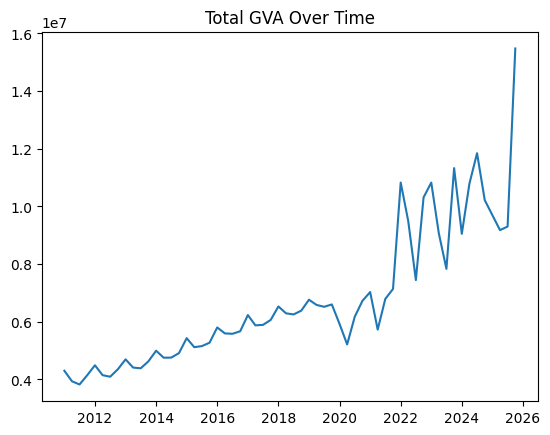

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ts)
plt.title("Total GVA Over Time")
plt.show()

### Step 4: Make Data Stationary

In [34]:
ts_diff = ts.diff().dropna()

### Step 5: Train ARIMA Model

In [35]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(1,1,1))  # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           gva_constant   No. Observations:                   59
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -895.846
Date:                Sat, 04 Apr 2026   AIC                           1797.692
Time:                        14:46:58   BIC                           1803.874
Sample:                             0   HQIC                          1800.100
                                 - 59                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0920      0.228      0.403      0.687      -0.355       0.539
ma.L1         -0.6027      0.192     -3.134      0.002      -0.980      -0.226
sigma2      1.462e+12   3.24e-14   4.51e+25      0.0

c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertibl

### Step 6: Forecast Future GDP

c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ACER\anaconda3\envs\first\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


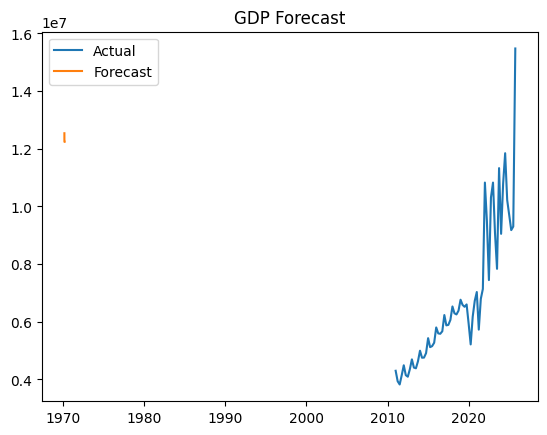

In [36]:
forecast = model_fit.forecast(steps=8)  # next 8 quarters

plt.figure()
plt.plot(ts, label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("GDP Forecast")
plt.show()

## ML PART 2: CLUSTERING

### Step 1: Create Clustering Dataset

In [37]:
cluster_df = df.groupby('industry').agg({
    'gva_constant': 'mean',
    'qoq_growth_pct': 'mean',
    'volatility': 'mean'
}).reset_index()

cluster_df.head()

,industry,gva_constant,qoq_growth_pct,volatility
0,"agriculture, livestock, forestry and fishing",514424.567176,487073.423438,974170.968666
1,construction,293927.523720,68045.434002,136098.896168
2,"electricity, gas, water supply & other utility...",76005.320885,185823.502170,371661.474322
3,"financial, real estate & professional services",757419.641310,5.234735,21.410648
4,manufacturing,560572.079450,21909.899915,43833.212391


### Step 2: Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

features = ['gva_constant', 'qoq_growth_pct', 'volatility']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

### Step 3: Apply KMeans

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

### Step 4: Visualize Clusters

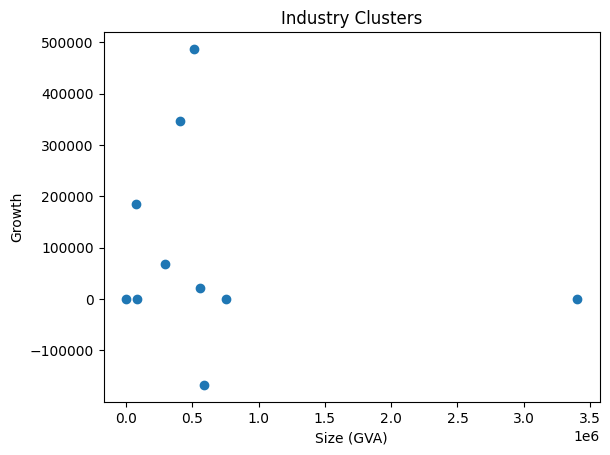

In [40]:
plt.figure()
plt.scatter(cluster_df['gva_constant'], cluster_df['qoq_growth_pct'])
plt.title("Industry Clusters")
plt.xlabel("Size (GVA)")
plt.ylabel("Growth")
plt.show()

### Step 5: Interpret Clusters

In [41]:
cluster_df.sort_values('cluster')

,industry,gva_constant,qoq_growth_pct,volatility,cluster
1,construction,2.939275e+05,68045.434002,136098.896168,0
3,"financial, real estate & professional services",7.574196e+05,5.234735,21.410648,0
5,mining and quarrying,8.222992e+04,5.125191,26.589050,0
4,manufacturing,5.605721e+05,21909.899915,43833.212391,0
7,total gross value added,3.401639e+06,4.285729,16.182941,0
8,total gva growth rate,6.145365e+00,-1.471746,54.487887,0
9,"trade, hotels, transport, communication & serv...",5.887760e+05,-167184.426356,334388.893171,0
0,"agriculture, livestock, forestry and fishing",5.144246e+05,487073.423438,974170.968666,1
6,"public administration, defence & other services",4.071638e+05,347196.814442,694410.924449,1
2,"electricity, gas, water supply & other utility...",7.600532e+04,185823.502170,371661.474322,2


### STEP 6 : SAVE FINAL DATASET

In [42]:
df_clean.to_csv("FINAL_CAPSTONE.csv", index=False)

In [43]:
df_final.to_csv("gva_feature_engineered.csv", index=False)

# THANK YOU